In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin
from feature.wavelet_package import WaveletPackage

class WaveletFeatures(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.featureExtractor = WaveletPackage()

    def fit(self, X, y=None):
        self.featureExtractor.fit(X, y)
        return self
    
    def transform(self, X):
        return self.featureExtractor.transform(X)

In [121]:
import numpy as np
from scipy.io import loadmat

def load_cwru_de_signal(mat_path):
    data = loadmat(mat_path)
    key = [k for k in data.keys() if 'DE_time' in k][0]
    signal = data[key]
    signal = np.squeeze(signal).astype(np.float32)
    return signal

# x = load_cwru_de_signal(mat_path)
# print(x.shape)
# print(x[:10])

def get_first_nth_segments(mat_path, nth, segment_length=1024):
    signal = load_cwru_de_signal(mat_path)
    n_segments = len(signal) // segment_length
    signal = signal[:n_segments * segment_length]
    segments = signal.reshape(n_segments, segment_length)
    return segments[:nth]

# mat_path = "raw_data/cwru/97.mat"
# segments = get_first_nth_segments(mat_path, nth=50)
# print(segments.shape)

# X = segments[:, :, np.newaxis]
print(X.shape)

(50, 1024, 1)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# seu wrapper
wf = WaveletFeatures()

# labels não são usados pelo extractor, então pode ser dummy
y_dummy = np.zeros(X.shape[0])

# extrai features WPD energy
X_wpd = wf.fit(X, y_dummy).transform(X)

print("X_wpd shape:", X_wpd.shape)
print("first feature vector:", X_wpd[0])

X_wpd shape: (50, 16)
first feature vector: [0.02133746 0.00199293 0.00085816 0.00106603 0.00104172 0.00087846
 0.00069507 0.00027045 0.00015154 0.00920743 0.00464444 0.00339942
 0.00183788 0.02386381 0.01194026 0.00929323]


explained variance: [0.1572872 0.134173 ]


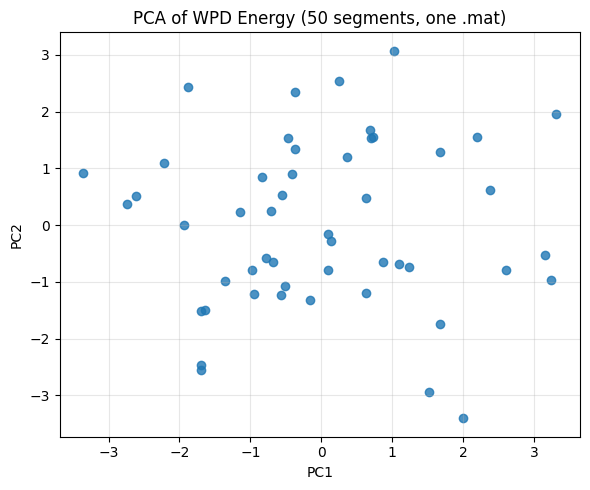

In [13]:
X_scaled = StandardScaler().fit_transform(X_wpd)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("explained variance:", pca.explained_variance_ratio_)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of WPD Energy (50 segments, one .mat)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------
# (1) Load + segment (50)
# -------------------------
def load_cwru_de_signal(mat_path):
    data = loadmat(mat_path)
    key = [k for k in data.keys() if 'DE_time' in k][0]
    x = np.squeeze(data[key]).astype(np.float32)
    return x

def first_50_segments(mat_path, segment_length=1024):
    x = load_cwru_de_signal(mat_path)
    n = len(x) // segment_length
    x = x[:n * segment_length]
    segs = x.reshape(n, segment_length)[:50]
    return segs[:, :, None]  # (50, 1024, 1)

# -------------------------
# (2) Compare 2 files
# -------------------------
def pca_compare_two_mats(mat_a, mat_b, segment_length=1024):
    Xa = first_50_segments(mat_a, segment_length=segment_length)
    Xb = first_50_segments(mat_b, segment_length=segment_length)

    X = np.concatenate([Xa, Xb], axis=0)  # (100, 1024, 1)
    domain = np.array(["A"] * Xa.shape[0] + ["B"] * Xb.shape[0])

    # WPD energy features using YOUR wrapper
    wf = WaveletFeatures()
    X_wpd = wf.fit(X, np.zeros(X.shape[0])).transform(X)  # (100, D)

    # PCA
    X_scaled = StandardScaler().fit_transform(X_wpd)
    pca = PCA(n_components=2, random_state=0)
    Z = pca.fit_transform(X_scaled)

    print("WPD shape:", X_wpd.shape)
    print("Explained variance:", pca.explained_variance_ratio_)

    # Plot
    plt.figure(figsize=(7, 6))
    plt.scatter(Z[domain=="A", 0], Z[domain=="A", 1], alpha=0.8, label="File A")
    plt.scatter(Z[domain=="B", 0], Z[domain=="B", 1], alpha=0.8, label="File B")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("PCA of WPD Energy (50 segments per file)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# (3) RUN (edit paths)
# -------------------------
mat_a = "raw_data/cwru/122.mat"
mat_b = "raw_data/cwru/123.mat"

pca_compare_two_mats(mat_a, mat_b, segment_length=1024)

NameError: name 'WaveletFeatures' is not defined

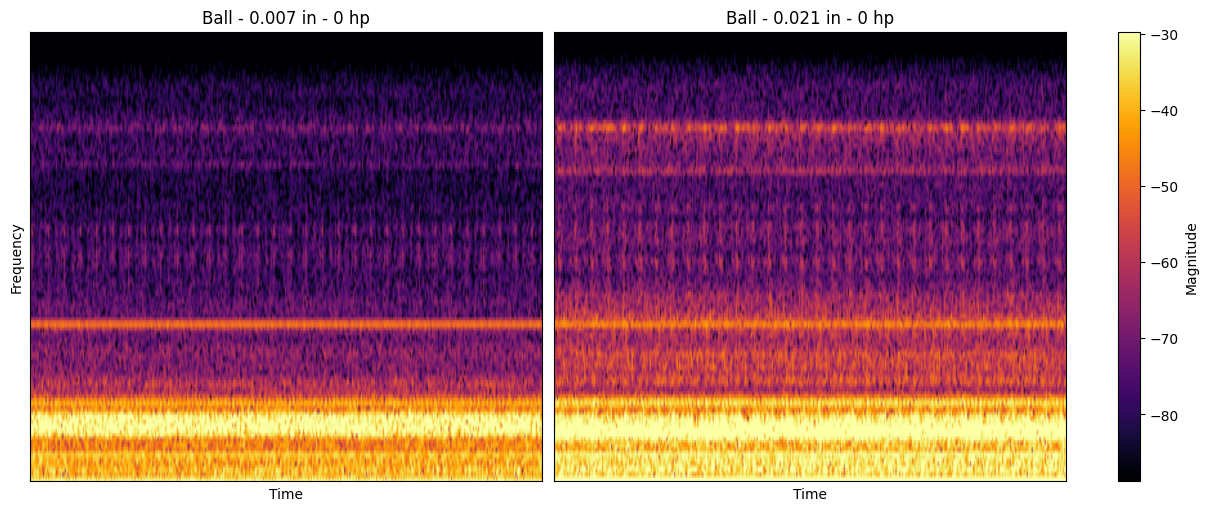

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import stft

def load_cwru_de_signal(mat_path):
    data = loadmat(mat_path)
    key = [k for k in data.keys() if 'DE_time' in k][0]
    x = np.squeeze(data[key]).astype(np.float32)
    return x

def plot_two_spectrograms(mat_a, mat_b, fs=48000, segment_length=1024, nperseg=256, noverlap=128):
    # Use exactly the same amount of data from each file for fair comparison
    n_samples = 50 * segment_length

    xa = load_cwru_de_signal(mat_a)[:n_samples]
    xb = load_cwru_de_signal(mat_b)[:n_samples]

    # STFT
    fa, ta, Za = stft(xa, fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)
    fb, tb, Zb = stft(xb, fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)

    Sa = 20 * np.log10(np.abs(Za) + 1e-12)  # dB
    Sb = 20 * np.log10(np.abs(Zb) + 1e-12)

    # Use same color scale for both plots (important!)
    vmin = np.percentile(np.concatenate([Sa.flatten(), Sb.flatten()]), 10)
    vmax = np.percentile(np.concatenate([Sa.flatten(), Sb.flatten()]), 95)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5),
        sharey=True,
        constrained_layout=True
    )

    im0 = axes[0].pcolormesh(ta, fa, Sa,
                            shading='gouraud',
                            vmin=vmin,
                            vmax=vmax,
                            cmap='inferno')

    im1 = axes[1].pcolormesh(tb, fb, Sb,
                            shading='gouraud',
                            vmin=vmin,
                            vmax=vmax,
                            cmap='inferno')

    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Fault Diameter = 0.007 in\nHorsepower = 1 HP")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Fault Diameter = 0.021 in\nHorsepower = 1 HP")    

    for ax in axes:
        ax.set_xticks([])  # Time ticks every 0.1s
        ax.set_yticks([])  # Frequency ticks every 1000 Hz

    # 🔥 Colorbar única, corretamente posicionada
    cbar = fig.colorbar(im1, ax=axes, location='right')
    cbar.set_label("Magnitude")

    plt.show()

# -------------------------
# RUN (edit paths)
# -------------------------
mat_a = "raw_data/cwru/122.mat"
mat_b = "raw_data/cwru/226.mat"

plot_two_spectrograms(mat_a, mat_b, fs=48000)

In [4]:
from scipy.io import loadmat
data = loadmat("raw_data/uored/B_11_1.mat")
data.keys(), data['B_11_1'].shape

(dict_keys(['__header__', '__version__', '__globals__', 'B_11_1']),
 (420000, 5))

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from typing import Optional, Sequence


def plot_tsne_three_scenarios(
    X_original: np.ndarray,
    y_original: Sequence,
    X_augmented: np.ndarray,
    y_augmented: Sequence,
    scenario_titles: tuple[str, str, str] = (
        "Original samples",
        "Augmented samples",
        "Original + Augmented",
    ),
    class_names: Optional[dict] = None,
    perplexity: float = 30.0,
    learning_rate: str | float = "auto",
    n_iter: int = 1000,
    random_state: int = 42,
    figsize: tuple[int, int] = (18, 5),
    alpha_original: float = 0.75,
    alpha_augmented: float = 0.75,
    s_original: int = 26,
    s_augmented: int = 34,
    save_path: Optional[str] = None,
    show: bool = True,
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plot t-SNE projections for three scenarios:
        (1) Original samples only
        (2) Augmented samples only
        (3) Original + Augmented together

    Parameters
    ----------
    X_original : np.ndarray
        Original feature matrix with shape (n_samples_original, n_features).
    y_original : Sequence
        Labels for original samples.
    X_augmented : np.ndarray
        Augmented feature matrix with shape (n_samples_augmented, n_features).
    y_augmented : Sequence
        Labels for augmented samples.
    scenario_titles : tuple[str, str, str], optional
        Titles for the three subplots.
    class_names : dict, optional
        Mapping from raw label -> display name.
        Example: {0: "Inner", 1: "Outer"}.
    perplexity : float, optional
        t-SNE perplexity.
    learning_rate : str or float, optional
        t-SNE learning rate.
    n_iter : int, optional
        Number of t-SNE iterations.
    random_state : int, optional
        Random seed for reproducibility.
    figsize : tuple[int, int], optional
        Figure size.
    alpha_original : float, optional
        Transparency for original samples.
    alpha_augmented : float, optional
        Transparency for augmented samples.
    s_original : int, optional
        Marker size for original samples.
    s_augmented : int, optional
        Marker size for augmented samples.
    save_path : str, optional
        Path to save the figure.
    show : bool, optional
        Whether to display the figure.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Generated figure.
    embedding : np.ndarray
        2D t-SNE embedding for all samples stacked together.
    """
    # -----------------------------
    # Basic validation
    # -----------------------------
    X_original = np.asarray(X_original)
    X_augmented = np.asarray(X_augmented)
    y_original = np.asarray(y_original)
    y_augmented = np.asarray(y_augmented)

    if X_original.ndim != 2 or X_augmented.ndim != 2:
        raise ValueError("X_original and X_augmented must be 2D arrays: (n_samples, n_features).")

    if X_original.shape[1] != X_augmented.shape[1]:
        raise ValueError("Original and augmented samples must have the same number of features.")

    if len(X_original) != len(y_original):
        raise ValueError("len(y_original) must match the number of original samples.")

    if len(X_augmented) != len(y_augmented):
        raise ValueError("len(y_augmented) must match the number of augmented samples.")

    # -----------------------------
    # Combine all samples so that
    # all subplots share the same
    # t-SNE coordinate system
    # -----------------------------
    X_all = np.vstack([X_original, X_augmented])
    y_all = np.concatenate([y_original, y_augmented])
    source_all = np.array(
        ["original"] * len(X_original) + ["augmented"] * len(X_augmented),
        dtype=object
    )

    # -----------------------------
    # Standardize features before t-SNE
    # -----------------------------
    scaler = StandardScaler()
    X_all_scaled = scaler.fit_transform(X_all)

    # -----------------------------
    # Compute t-SNE embedding
    # -----------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=n_iter,
        init="pca",
        random_state=random_state,
    )
    embedding = tsne.fit_transform(X_all_scaled)

    # -----------------------------
    # Masks for the three scenarios
    # -----------------------------
    mask_original = source_all == "original"
    mask_augmented = source_all == "augmented"
    mask_all = np.ones(len(X_all), dtype=bool)

    masks = [mask_original, mask_augmented, mask_all]

    # -----------------------------
    # Color palette by class
    # -----------------------------
    unique_labels = np.unique(y_all)
    cmap = plt.cm.get_cmap("tab10", len(unique_labels))
    color_map = {label: cmap(i) for i, label in enumerate(unique_labels)}

    # -----------------------------
    # Label formatter
    # -----------------------------
    def format_label(label):
        return class_names[label] if class_names is not None and label in class_names else str(label)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    for ax, mask, title in zip(axes, masks, scenario_titles):
        if np.array_equal(mask, mask_all):
            # Scenario 3: overlay original + augmented
            for label in unique_labels:
                class_mask = y_all == label

                current_original = mask_original & class_mask
                current_augmented = mask_augmented & class_mask

                if np.any(current_original):
                    ax.scatter(
                        embedding[current_original, 0],
                        embedding[current_original, 1],
                        c=[color_map[label]],
                        marker="o",
                        s=s_original,
                        alpha=alpha_original,
                        edgecolors="none",
                        label=f"{format_label(label)} (original)",
                    )

                if np.any(current_augmented):
                    ax.scatter(
                        embedding[current_augmented, 0],
                        embedding[current_augmented, 1],
                        c=[color_map[label]],
                        marker="v",
                        s=s_augmented,
                        alpha=alpha_augmented,
                        edgecolors="none",
                        label=f"{format_label(label)} (augmented)",
                    )
        else:
            # Scenario 1 or 2
            current_source = "original" if np.array_equal(mask, mask_original) else "augmented"
            current_marker = "o" if current_source == "original" else "v"
            current_size = s_original if current_source == "original" else s_augmented
            current_alpha = alpha_original if current_source == "original" else alpha_augmented

            for label in unique_labels:
                class_mask = (y_all == label) & mask
                if not np.any(class_mask):
                    continue

                ax.scatter(
                    embedding[class_mask, 0],
                    embedding[class_mask, 1],
                    c=[color_map[label]],
                    marker=current_marker,
                    s=current_size,
                    alpha=current_alpha,
                    edgecolors="none",
                    label=format_label(label),
                )

        ax.set_title(title)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="best")

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, embedding

In [16]:
files_list = [109, 110, 111, 112, 174, 175, 176, 177, 213]
files_path = [f"raw_data/cwru/{f}.mat" for f in files_list]
segments_list = [get_first_nth_segments(path, nth=10, segment_length=1024) for path in files_path]
segments_array = np.array(segments_list)
print("Segments array shape:", segments_array.shape)

Segments array shape: (9, 10, 1024)


## Utils

In [110]:
import numpy as np

from utils.assesment import holdout
from dataset.utils import (
    read_registers_from_config,
    filter_registers_by_key_value_sequence,
    load_matlab_acquisition,
    get_acquisition_data,          # loads full acquisition (with download fallback)
    split_acquisition,             # segments an acquisition into fixed-length windows
    target_array,                  # creates y array for a given label/length
)

segment_length = 1024


#            ### training -------------------------###   ### testing --###
papers_split = [(['0', '1', '2', '3'], ['0.007', '0.014']), (['0'], ['0.021'])]
# papers_split = [(['0', '1', '2', '3'], ['0.007', '0.014']), (['0', '1', '2', '3'], ['0.021'])]
# papers_split = [(['0', '1', '2', '3'], ['0.007', '0.021']), (['0', '1', '2', '3'], ['0.014'])]
# papers_split = [(['0', '1', '2', '3'], ['0.014', '0.021']), (['0', '1', '2', '3'], ['0.007'])]

# ---------------------------------------------------------------------
# Augmentation at ACQUISITION level (NOT segment level)
# Adapted rule (your request):
#   same load + same condition (class), but different severities.
#
# EXACT Mode 3 (paper):
#   - FFT EACH single sample/acquisition individually
#   - Random superposition in frequency domain
#   - IFFT back to time domain
#   - THEN segment
# ---------------------------------------------------------------------

def _rfft_acquisition(acq: np.ndarray) -> np.ndarray:
    """
    acq: (T, C) time-domain acquisition
    returns: (F, C) complex spectrum via rFFT along time axis
    """
    return np.fft.rfft(acq, axis=0)

def _irfft_acquisition(Xf: np.ndarray, n_time: int) -> np.ndarray:
    """
    Xf: (F, C) complex spectrum
    returns: (T, C) real acquisition via irFFT with length n_time
    """
    x = np.fft.irfft(Xf, n=n_time, axis=0)
    return x.astype(np.float32)

def _align_acquisitions(a: np.ndarray, b: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Ensures both acquisitions have same time length by trimming to the minimum length.
    This is required to superpose spectra bin-to-bin.
    """
    T = min(a.shape[0], b.shape[0])
    return a[:T], b[:T], T


def _mix_two_acquisitions(acq_a: np.ndarray, acq_b: np.ndarray) -> np.ndarray:
    acq_a, acq_b, T = _align_acquisitions(acq_a, acq_b)
    Xf_a = _rfft_acquisition(acq_a)
    Xf_b = _rfft_acquisition(acq_b)
    Xf_mix = (Xf_a + Xf_b)
    acq_mix = _irfft_acquisition(Xf_mix, n_time=T)
    return acq_mix


# Same load + same condition (class), but different severities.
def _build_augmented_segments_from_registers(
    registers: list[dict],
    raw_dir_path: str,
    channels_columns: list[str],
    segment_length: int,
    load_acquisition_func,
    rng: np.random.Generator,
    mixes_per_pair: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
   
    # Cache full acquisitions:
    # groups[(load, condition)][severity] = [acq1, acq2, ...]
    groups: dict[tuple[str, str], dict[str, list[np.ndarray]]] = {}

    for reg in registers:
        ld = str(reg.get("load"))
        cond = str(reg.get("condition"))
        sev = str(reg.get("severity"))

        acq = get_acquisition_data(raw_dir_path, channels_columns, load_acquisition_func, reg)
        acq = acq.astype(np.float32)

        key = (ld, cond)
        groups.setdefault(key, {}).setdefault(sev, []).append(acq)
    
    X_aug_list: list[np.ndarray] = []
    y_aug_list: list[np.ndarray] = []

    for (ld, cond), sev_dict in groups.items():
        sevs = sorted(sev_dict.keys())
        if len(sevs) < 2:
            continue

        # Unique severity pairs
        for i in range(len(sevs)):
            for j in range(i + 1, len(sevs)):
                sev_a, sev_b = sevs[i], sevs[j]
                list_a = sev_dict.get(sev_a, [])
                list_b = sev_dict.get(sev_b, [])
                if not list_a or not list_b:
                    continue

                # Create mixed samples by random pairing of single acquisitions
                # A "natural" count is min(len_a, len_b); mixes_per_pair repeats that process.
                n_base = min(len(list_a), len(list_b))
                n_new = mixes_per_pair * n_base
                if n_new <= 0:
                    continue

                # Random pairing indices (with replacement if mixes_per_pair > 1)
                idx_a = rng.integers(0, len(list_a), size=n_new)
                idx_b = rng.integers(0, len(list_b), size=n_new)

                for ka, kb in zip(idx_a, idx_b):
                    acq_mix = _mix_two_acquisitions(list_a[ka], list_b[kb])

                    # Segment AFTER mixing (required by your request and matches the pipeline idea)
                    segs = split_acquisition(acq_mix, segment_length=segment_length)
                    if segs.shape[0] == 0:
                        continue

                    X_aug_list.append(segs)
                    y_aug_list.append(target_array(cond, segs.shape[0]))

    if not X_aug_list:
        return (
            np.empty((0, segment_length, 1), dtype=np.float32),
            np.empty((0,), dtype='U10')
        )

    X_aug = np.concatenate(X_aug_list, axis=0)
    y_aug = np.concatenate(y_aug_list, axis=0)
    return X_aug, y_aug

def prepare_segments_and_targets(segment_length, register, acquisition):
    segments = split_acquisition(acquisition, segment_length=segment_length)
    targets = target_array(register['condition'], segments.shape[0])
    return segments,targets

def extract_segments_and_targets(raw_dir_path, channels_columns, segment_length, load_acquisition_func, register):
    acquisition = get_acquisition_data(raw_dir_path, channels_columns, load_acquisition_func, register)[:16384]
    segments, targets = prepare_segments_and_targets(segment_length, register, acquisition)
    return segments,targets


def get_X_y_augmented_acquisition_level(
    registers,
    raw_dir_path,
    channels_columns,
    segment_length,
    load_acquisition_func,
    rng: np.random.Generator,
    mixes_per_pair: int = 1,
    augment: bool = True,   # <--- NEW
):
    # ORIGINAL (always)
    X_list = []
    y_list = []

    if len(registers) > 0:
        for reg in registers:
            segs, targets = extract_segments_and_targets(
                raw_dir_path, channels_columns, segment_length, load_acquisition_func, reg
            )
            X_list.append(segs.astype(np.float32))
            y_list.append(targets)

    if not X_list:
        X_orig = np.empty((0, segment_length, 1), dtype=np.float32)
        y_orig = np.empty((0,), dtype="U10")
    else:
        X_orig = np.concatenate(X_list, axis=0)
        y_orig = np.concatenate(y_list, axis=0)

    # --- NO augmentation ---
    if not augment:
        return X_orig, y_orig

    # AUGMENTED (only if augment=True)
    X_aug, y_aug = _build_augmented_segments_from_registers(
        registers=registers,
        raw_dir_path=raw_dir_path,
        channels_columns=channels_columns,
        segment_length=segment_length,
        load_acquisition_func=load_acquisition_func,
        rng=rng,
        mixes_per_pair=mixes_per_pair,
    )

    X_out = np.concatenate([X_orig, X_aug], axis=0)
    y_out = np.concatenate([y_orig, y_aug], axis=0)
    return X_aug, y_aug



def get_list_of_X_y_mode3_by_load(
    list_of_folds,
    raw_dir_path,
    channels_columns,
    segment_length,
    load_acquisition_func,
    seed: int = 0,
    mixes_per_pair: int = 1,
    test_fold_index: int | None = None,
    augment=False,
):
    """
    Returns list_of_X_y where:
      - training folds: augmented (Mode 3, acquisition-level)
      - test fold: NOT augmented
    """
    rng = np.random.default_rng(seed)
    list_of_X_y = []

    for fold_idx, fold in enumerate(list_of_folds):
        # Test fold untouched
        if test_fold_index is not None and fold_idx == test_fold_index:
            X_list = []
            y_list = []
            if len(fold) == 0:
                X = np.empty((0, segment_length, 1), dtype=np.float32)
                y = np.empty((0,), dtype='U10')
            else:
                for reg in fold:
                    segs, targets = extract_segments_and_targets(
                        raw_dir_path, channels_columns, segment_length, load_acquisition_func, reg
                    )
                    X_list.append(segs.astype(np.float32))
                    y_list.append(targets)

                X = np.concatenate(X_list, axis=0) if X_list else np.empty((0, segment_length, 1), dtype=np.float32)
                y = np.concatenate(y_list, axis=0) if y_list else np.empty((0,), dtype='U10')

            list_of_X_y.append((X, y))
            continue

        # Training folds: augmented at acquisition-level
        X, y = get_X_y_augmented_acquisition_level(
            registers=fold,
            raw_dir_path=raw_dir_path,
            channels_columns=channels_columns,
            segment_length=segment_length,
            load_acquisition_func=load_acquisition_func,
            rng=rng,
            mixes_per_pair=mixes_per_pair,
            augment=augment
        )
        list_of_X_y.append((X, y))

    return list_of_X_y


# ---------------------------------------------------------------------
# Fold construction (same structure as sehri_et_al.py)
# ---------------------------------------------------------------------

def get_papers_split(loads, severities, condition=['Inner Race', 'Outer Race', 'Ball']):
    sample_rate = "48000"
    config_file = "dataset/cwru/config.csv"
    prlzs = ['None', '6']

    registers = read_registers_from_config(config_file)
    filtered = filter_registers_by_key_value_sequence(
        registers,
        [
            ('sample_rate', [sample_rate]),
            ('load', loads),
            ('condition', condition),
            ('severity', severities),
            ('prlz', prlzs),
        ]
    )
    return filtered


def get_list_of_papers_splits(papers_split=papers_split, condition=['Inner Race', 'Outer Race', 'Ball']):
    folds = []
    for loads, severities in papers_split:
        folds.append(get_papers_split(loads, severities, condition))
    return folds


# ---------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------

def run_papers_experiment(model, list_of_metrics, mixes_per_pair: int = 1, seed: int = 0, augment: bool = False):
    """
    Hold-out experiment with Mode 3 augmentation applied ONLY on training fold(s).
    Test fold is kept clean.
    Augmentation is performed at ACQUISITION level (FFT mix -> IFFT -> segment).
    """
    test_fold_index = 1
    list_of_folds = get_list_of_papers_splits()

    list_of_X_y = get_list_of_X_y_mode3_by_load(
        list_of_folds,
        raw_dir_path="raw_data/cwru",
        channels_columns=['DE'],
        segment_length=segment_length,
        load_acquisition_func=load_matlab_acquisition,
        mixes_per_pair=mixes_per_pair,
        seed=seed,
        test_fold_index=test_fold_index,
        augment=augment
    )

    scores = holdout(model, list_of_X_y, test_fold_index=test_fold_index, list_of_metrics=list_of_metrics)
    return scores


## Plot functions

### plot_tsne_multidomain_three_scenarios

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from typing import Optional, Callable


def _flatten_signals(X: np.ndarray) -> np.ndarray:
    """
    Flatten signals from shape (n_samples, length, channels) to (n_samples, n_features).
    """
    if X.ndim < 2:
        raise ValueError("Input array must have at least 2 dimensions.")
    return X.reshape(X.shape[0], -1)


def plot_tsne_multidomain_three_scenarios(
    X_train_dom_1: np.ndarray,
    X_train_dom_2: np.ndarray,
    X_test: np.ndarray,
    X_augmented: np.ndarray,
    feature_extractor: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    domain_names: tuple[str, str, str, str] = (
        "Train D1",
        "Train D2",
        "Test",
        "Augmented",
    ),
    scenario_titles: tuple[str, str, str] = (
        "(a) Original data",
        "(b) Augmented data",
        "(c) Original + augmented",
    ),
    perplexity: float = 20.0,
    learning_rate: str | float = "auto",
    max_iter: int = 1500,
    random_state: int = 42,
    figsize: tuple[int, int] = (18, 5),
    save_path: Optional[str] = None,
    show: bool = True,
):
    # -----------------------------
    # Step 1: feature extraction
    # -----------------------------
    if feature_extractor is None:
        feature_extractor = _flatten_signals

    F_dom_1 = feature_extractor(X_train_dom_1)
    F_dom_2 = feature_extractor(X_train_dom_2)
    F_test = feature_extractor(X_test)
    F_aug = feature_extractor(X_augmented)

    # -----------------------------
    # Step 2: stack all samples
    # -----------------------------
    X_all = np.vstack([F_dom_1, F_dom_2, F_test, F_aug])

    source_labels = np.array(
        [domain_names[0]] * len(F_dom_1) +
        [domain_names[1]] * len(F_dom_2) +
        [domain_names[2]] * len(F_test) +
        [domain_names[3]] * len(F_aug),
        dtype=object
    )

    # -----------------------------
    # Step 3: standardization
    # -----------------------------
    scaler = StandardScaler()
    X_all_scaled = scaler.fit_transform(X_all)

    # -----------------------------
    # Step 4: t-SNE on ALL samples
    # Shared embedding for all panels
    # -----------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        init="pca",
        random_state=random_state,
    )
    embedding = tsne.fit_transform(X_all_scaled)

    # -----------------------------
    # Step 5: masks
    # -----------------------------
    mask_dom_1 = source_labels == domain_names[0]
    mask_dom_2 = source_labels == domain_names[1]
    mask_test = source_labels == domain_names[2]
    mask_aug = source_labels == domain_names[3]

    # Scenario masks
    mask_original = mask_dom_1 | mask_dom_2 | mask_test
    mask_aug_only = mask_aug
    mask_all = np.ones(len(source_labels), dtype=bool)

    # -----------------------------
    # Step 6: plot style
    # -----------------------------
    styles = {
        domain_names[0]: dict(marker="o", s=28, alpha=0.75, color="#1f77b4"),  # blue
        domain_names[1]: dict(marker="o", s=28, alpha=0.75, color="#2ca02c"),  # green
        domain_names[2]: dict(marker="s", s=34, alpha=0.85, color="#ff7f0e"),  # orange
        domain_names[3]: dict(marker="v", s=34, alpha=0.75, color="#e377c2"),  # pink
    }

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    def _plot_group(ax, group_name: str, mask_group: np.ndarray):
        if np.any(mask_group):
            style = styles[group_name]
            ax.scatter(
                embedding[mask_group, 0],
                embedding[mask_group, 1],
                label=group_name,
                marker=style["marker"],
                s=style["s"],
                alpha=style["alpha"],
                c=style["color"],
                edgecolors="none",
            )

    # -----------------------------
    # Panel (a): Original data
    # -----------------------------
    ax = axes[0]
    _plot_group(ax, domain_names[0], mask_dom_1)
    _plot_group(ax, domain_names[1], mask_dom_2)
    _plot_group(ax, domain_names[2], mask_test)
    ax.set_title(scenario_titles[0])
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

    # -----------------------------
    # Panel (b): Augmented only
    # -----------------------------
    ax = axes[1]
    _plot_group(ax, domain_names[3], mask_aug)
    ax.set_title(scenario_titles[1])
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

    # -----------------------------
    # Panel (c): Original + Augmented
    # -----------------------------
    ax = axes[2]
    _plot_group(ax, domain_names[0], mask_dom_1)
    _plot_group(ax, domain_names[1], mask_dom_2)
    _plot_group(ax, domain_names[2], mask_test)
    _plot_group(ax, domain_names[3], mask_aug)
    ax.set_title(scenario_titles[2])
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    metadata = {
        "mask_dom_1": mask_dom_1,
        "mask_dom_2": mask_dom_2,
        "mask_test": mask_test,
        "mask_aug": mask_aug,
        "mask_original": mask_original,
        "mask_aug_only": mask_aug_only,
        "mask_all": mask_all,
        "source_labels": source_labels,
    }

    return fig, embedding, metadata

### plot_tsne_class_comparison

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from typing import Optional, Callable


def _flatten_signals(X: np.ndarray) -> np.ndarray:
    """
    Flatten signals from shape (n_samples, length, channels) to (n_samples, n_features).
    """
    if X.ndim < 2:
        raise ValueError("Input array must have at least 2 dimensions.")
    return X.reshape(X.shape[0], -1)


def plot_tsne_class_comparison(
    Xtr_ball: np.ndarray,
    Xtr_inner: np.ndarray,
    Xtr_outer: np.ndarray,
    Xte_ball: np.ndarray,
    Xte_inner: np.ndarray,
    Xte_outer: np.ndarray,
    Xtr_ball_aug: np.ndarray,
    Xtr_inner_aug: np.ndarray,
    Xtr_outer_aug: np.ndarray,
    feature_extractor: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    scenario_titles: tuple[str, str, str] = (
        "(a) Original train + test",
        "(b) Augmented train only",
        "(c) Original + augmented + test",
    ),
    perplexity: float = 20.0,
    learning_rate: str | float = "auto",
    max_iter: int = 1500,
    random_state: int = 42,
    figsize: tuple[int, int] = (18, 5),
    save_path: Optional[str] = None,
    show: bool = True,
):

    if feature_extractor is None:
        feature_extractor = _flatten_signals

    # -----------------------------
    # Feature extraction
    # -----------------------------
    F_tr_ball = feature_extractor(Xtr_ball)
    F_tr_inner = feature_extractor(Xtr_inner)
    F_tr_outer = feature_extractor(Xtr_outer)

    F_te_ball = feature_extractor(Xte_ball)
    F_te_inner = feature_extractor(Xte_inner)
    F_te_outer = feature_extractor(Xte_outer)

    F_aug_ball = feature_extractor(Xtr_ball_aug)
    F_aug_inner = feature_extractor(Xtr_inner_aug)
    F_aug_outer = feature_extractor(Xtr_outer_aug)

    # -----------------------------
    # Stack all samples
    # -----------------------------
    X_all = np.vstack([
        F_tr_ball, F_tr_inner, F_tr_outer,
        F_te_ball, F_te_inner, F_te_outer,
        F_aug_ball, F_aug_inner, F_aug_outer
    ])

    class_labels = np.array(
        ["Ball"] * len(F_tr_ball) +
        ["Inner"] * len(F_tr_inner) +
        ["Outer"] * len(F_tr_outer) +
        ["Ball"] * len(F_te_ball) +
        ["Inner"] * len(F_te_inner) +
        ["Outer"] * len(F_te_outer) +
        ["Ball"] * len(F_aug_ball) +
        ["Inner"] * len(F_aug_inner) +
        ["Outer"] * len(F_aug_outer),
        dtype=object
    )

    source_labels = np.array(
        ["train"] * len(F_tr_ball) +
        ["train"] * len(F_tr_inner) +
        ["train"] * len(F_tr_outer) +
        ["test"] * len(F_te_ball) +
        ["test"] * len(F_te_inner) +
        ["test"] * len(F_te_outer) +
        ["augmented"] * len(F_aug_ball) +
        ["augmented"] * len(F_aug_inner) +
        ["augmented"] * len(F_aug_outer),
        dtype=object
    )

    # -----------------------------
    # Standardization
    # -----------------------------
    scaler = StandardScaler()
    X_all_scaled = scaler.fit_transform(X_all)

    # -----------------------------
    # t-SNE
    # -----------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        init="pca",
        random_state=random_state,
    )
    embedding = tsne.fit_transform(X_all_scaled)

    # -----------------------------
    # Masks
    # -----------------------------
    mask_train = source_labels == "train"
    mask_test = source_labels == "test"
    mask_aug = source_labels == "augmented"

    mask_original = mask_train | mask_test
    mask_augmented_only = mask_aug
    mask_all = np.ones(len(X_all), dtype=bool)

    scenario_masks = [mask_original, mask_augmented_only, mask_all]

    # -----------------------------
    # Plot style
    # color = class
    # marker = source
    # -----------------------------
    class_colors = {
        "Ball": "#1f77b4",   # blue
        "Inner": "#2ca02c",  # green
        "Outer": "#d62728",  # red
    }

    source_markers = {
        "train": "o",
        "test": "s",
        "augmented": "v",
    }

    source_sizes = {
        "train": 28,
        "test": 36,
        "augmented": 34,
    }

    source_alpha = {
        "train": 0.75,
        "test": 0.85,
        "augmented": 0.75,
    }

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    for ax, scenario_mask, title in zip(axes, scenario_masks, scenario_titles):
        # Plot by class and source
        for cls in ["Ball", "Inner", "Outer"]:
            for src in ["train", "test", "augmented"]:
                current_mask = (class_labels == cls) & (source_labels == src) & scenario_mask
                if not np.any(current_mask):
                    continue

                ax.scatter(
                    embedding[current_mask, 0],
                    embedding[current_mask, 1],
                    c=class_colors[cls],
                    marker=source_markers[src],
                    s=source_sizes[src],
                    alpha=source_alpha[src],
                    edgecolors="none",
                    label=f"{cls} ({src})"
                )

        ax.set_title(title)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.grid(True, alpha=0.25)

        # Remove duplicated legend entries
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), fontsize=8, loc="best")

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    metadata = {
        "class_labels": class_labels,
        "source_labels": source_labels,
        "mask_train": mask_train,
        "mask_test": mask_test,
        "mask_aug": mask_aug,
        "mask_original": mask_original,
        "mask_augmented_only": mask_augmented_only,
        "mask_all": mask_all,
    }

    return fig, embedding, metadata

### plot_tsne_class_comparison_wpt

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from feature.wavelet_package import WaveletPackage


def plot_tsne_class_comparison_wpt(
    Xtr_ball,
    Xtr_inner,
    Xtr_outer,
    Xte_ball,
    Xte_inner,
    Xte_outer,
    Xtr_ball_aug,
    Xtr_inner_aug,
    Xtr_outer_aug,
    wavelet='db4',
    mode='symmetric',
    maxlevel=4,
    perplexity=20.0,
    learning_rate='auto',
    max_iter=1500,
    random_state=42,
    figsize=(18, 5),
    save_path=None,
    show=True,
):
    """
    Plot t-SNE using WPT energy features for three scenarios:
        (a) Original train + test
        (b) Augmented train only
        (c) Original + augmented + test
    """

    # -----------------------------------
    # 1) Build WPT feature extractor
    # -----------------------------------
    wpt = WaveletPackage(
        wavelet=wavelet,
        mode=mode,
        maxlevel=maxlevel
    )

    # -----------------------------------
    # 2) Extract WPT features
    # -----------------------------------
    F_tr_ball = wpt.transform(Xtr_ball)
    F_tr_inner = wpt.transform(Xtr_inner)
    F_tr_outer = wpt.transform(Xtr_outer)

    F_te_ball = wpt.transform(Xte_ball)
    F_te_inner = wpt.transform(Xte_inner)
    F_te_outer = wpt.transform(Xte_outer)

    F_aug_ball = wpt.transform(Xtr_ball_aug)
    F_aug_inner = wpt.transform(Xtr_inner_aug)
    F_aug_outer = wpt.transform(Xtr_outer_aug)

    # -----------------------------------
    # 3) Stack all features
    # -----------------------------------
    X_all = np.vstack([
        F_tr_ball, F_tr_inner, F_tr_outer,
        F_te_ball, F_te_inner, F_te_outer,
        F_aug_ball, F_aug_inner, F_aug_outer
    ])

    class_labels = np.array(
        ["Ball"] * len(F_tr_ball) +
        ["Inner"] * len(F_tr_inner) +
        ["Outer"] * len(F_tr_outer) +
        ["Ball"] * len(F_te_ball) +
        ["Inner"] * len(F_te_inner) +
        ["Outer"] * len(F_te_outer) +
        ["Ball"] * len(F_aug_ball) +
        ["Inner"] * len(F_aug_inner) +
        ["Outer"] * len(F_aug_outer),
        dtype=object
    )

    source_labels = np.array(
        ["train"] * len(F_tr_ball) +
        ["train"] * len(F_tr_inner) +
        ["train"] * len(F_tr_outer) +
        ["test"] * len(F_te_ball) +
        ["test"] * len(F_te_inner) +
        ["test"] * len(F_te_outer) +
        ["augmented"] * len(F_aug_ball) +
        ["augmented"] * len(F_aug_inner) +
        ["augmented"] * len(F_aug_outer),
        dtype=object
    )

    # -----------------------------------
    # 4) Standardize features
    # -----------------------------------
    scaler = StandardScaler()
    X_all_scaled = scaler.fit_transform(X_all)

    # -----------------------------------
    # 5) Run t-SNE on all samples together
    #     so all panels share same embedding
    # -----------------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        init="pca",
        random_state=random_state,
    )
    embedding = tsne.fit_transform(X_all_scaled)

    # -----------------------------------
    # 6) Define masks for scenarios
    # -----------------------------------
    mask_train = source_labels == "train"
    mask_test = source_labels == "test"
    mask_aug = source_labels == "augmented"

    mask_original = mask_train | mask_test
    mask_augmented_only = mask_aug
    mask_all = np.ones(len(X_all), dtype=bool)

    scenario_masks = [mask_original, mask_augmented_only, mask_all]
    scenario_titles = [
        "(a) Original train + test",
        "(b) Augmented train only",
        "(c) Original + augmented + test"
    ]

    # -----------------------------------
    # 7) Visual style
    #     color = class
    #     marker = source
    # -----------------------------------
    class_colors = {
        "Ball": "#1f77b4",   # blue
        "Inner": "#2ca02c",  # green
        "Outer": "#d62728",  # red
    }

    source_markers = {
        "train": "o",
        "test": "s",
        "augmented": "v",
    }

    source_sizes = {
        "train": 28,
        "test": 38,
        "augmented": 34,
    }

    source_alpha = {
        "train": 0.75,
        "test": 0.85,
        "augmented": 0.75,
    }

    # -----------------------------------
    # 8) Plot
    # -----------------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    for ax, scenario_mask, title in zip(axes, scenario_masks, scenario_titles):
        for cls in ["Ball", "Inner", "Outer"]:
            for src in ["train", "test", "augmented"]:
                current_mask = (
                    (class_labels == cls) &
                    (source_labels == src) &
                    scenario_mask
                )

                if not np.any(current_mask):
                    continue

                ax.scatter(
                    embedding[current_mask, 0],
                    embedding[current_mask, 1],
                    c=class_colors[cls],
                    marker=source_markers[src],
                    s=source_sizes[src],
                    alpha=source_alpha[src],
                    edgecolors="none",
                    label=f"{cls} ({src})"
                )

        ax.set_title(title)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.grid(True, alpha=0.25)

        # remove duplicate legend entries
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), fontsize=8, loc="best")

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    metadata = {
        "features_all": X_all,
        "embedding": embedding,
        "class_labels": class_labels,
        "source_labels": source_labels,
        "mask_train": mask_train,
        "mask_test": mask_test,
        "mask_aug": mask_aug,
    }

    return fig, embedding, metadata

### Spectrum calculation

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert


def mix_signals_in_frequency_domain(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """
    Mix two real-valued signals in the frequency domain and return the synthetic
    time-domain signal.

    Both signals must have the same length.
    """
    if x1.shape != x2.shape:
        raise ValueError("x1 and x2 must have the same shape.")

    X1 = np.fft.rfft(x1)
    X2 = np.fft.rfft(x2)
    Xmix = X1 + X2
    xmix = np.fft.irfft(Xmix, n=len(x1))
    return xmix


def compute_amplitude_spectrum(x: np.ndarray, fs: float):
    """
    Compute one-sided amplitude spectrum.
    """
    n = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    amp = np.abs(X) / n
    amp[1:-1] *= 2.0
    return freqs, amp


def compute_envelope_spectrum(x: np.ndarray, fs: float):
    """
    Compute envelope spectrum using the Hilbert transform.
    """
    analytic = hilbert(x)
    envelope = np.abs(analytic)
    return compute_amplitude_spectrum(envelope, fs)


def plot_frequency_comparison(
    x1: np.ndarray,
    x2: np.ndarray,
    xmix: np.ndarray,
    fs: float,
    fault_freqs: dict | None = None,
    max_freq: float | None = None,
    title_prefix: str = "Frequency-domain comparison",
    save_path: str | None = None,
):
    """
    Plot raw amplitude spectra for original signals and mixed signal.
    """
    f1, a1 = compute_amplitude_spectrum(x1, fs)
    f2, a2 = compute_amplitude_spectrum(x2, fs)
    fm, am = compute_amplitude_spectrum(xmix, fs)

    if max_freq is None:
        max_freq = fs / 2

    mask1 = f1 <= max_freq
    mask2 = f2 <= max_freq
    maskm = fm <= max_freq

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

    axes[0].plot(f1[mask1], a1[mask1], linewidth=1.0)
    axes[0].set_title(f"{title_prefix} - Signal 1")
    axes[0].set_xlabel("Frequency (Hz)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(f2[mask2], a2[mask2], linewidth=1.0)
    axes[1].set_title(f"{title_prefix} - Signal 2")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(fm[maskm], am[maskm], linewidth=1.0)
    axes[2].set_title(f"{title_prefix} - Mixed")
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Amplitude")
    axes[2].grid(True, alpha=0.3)

    if fault_freqs is not None:
        for ax in axes:
            for name, freq in fault_freqs.items():
                if freq <= max_freq:
                    ax.axvline(freq, linestyle="--", linewidth=1.0, alpha=0.8)
                    ax.text(freq, ax.get_ylim()[1] * 0.9, name, rotation=90,
                            va="top", ha="right", fontsize=8)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


def plot_envelope_frequency_comparison(
    x1: np.ndarray,
    x2: np.ndarray,
    xmix: np.ndarray,
    fs: float,
    fault_freqs: dict | None = None,
    max_freq: float = 500.0,
    title_prefix: str = "Envelope spectrum comparison",
    save_path: str | None = None,
):
    """
    Plot envelope spectra for original signals and mixed signal.
    This is often more informative for bearing characteristic frequencies.
    """
    f1, a1 = compute_envelope_spectrum(x1, fs)
    f2, a2 = compute_envelope_spectrum(x2, fs)
    fm, am = compute_envelope_spectrum(xmix, fs)

    mask1 = f1 <= max_freq
    mask2 = f2 <= max_freq
    maskm = fm <= max_freq

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

    axes[0].plot(f1[mask1], a1[mask1], linewidth=1.0)
    axes[0].set_title(f"{title_prefix} - Signal 1")
    axes[0].set_xlabel("Frequency (Hz)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(f2[mask2], a2[mask2], linewidth=1.0)
    axes[1].set_title(f"{title_prefix} - Signal 2")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(fm[maskm], am[maskm], linewidth=1.0)
    axes[2].set_title(f"{title_prefix} - Mixed")
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Amplitude")
    axes[2].grid(True, alpha=0.3)

    if fault_freqs is not None:
        for ax in axes:
            for name, freq in fault_freqs.items():
                if freq <= max_freq:
                    ax.axvline(freq, linestyle="--", linewidth=1.0, alpha=0.8)
                    ax.text(freq, ax.get_ylim()[1] * 0.9, name, rotation=90,
                            va="top", ha="right", fontsize=8)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig

### Spectrum

In [120]:
def bearing_characteristic_frequencies(
    rpm: float,
    n_balls: int,
    ball_diameter: float,
    pitch_diameter: float,
    contact_angle_deg: float = 0.0,
):
    """
    Compute characteristic bearing fault frequencies.

    Parameters
    ----------
    rpm : float
        Shaft speed in rpm.
    n_balls : int
        Number of rolling elements.
    ball_diameter : float
        Ball diameter.
    pitch_diameter : float
        Pitch diameter.
    contact_angle_deg : float
        Contact angle in degrees.
    """
    fr = rpm / 60.0
    theta = np.deg2rad(contact_angle_deg)
    ratio = (ball_diameter / pitch_diameter) * np.cos(theta)

    ftf = 0.5 * fr * (1 - ratio)
    bpfo = 0.5 * n_balls * fr * (1 - ratio)
    bpfi = 0.5 * n_balls * fr * (1 + ratio)
    bsf = (pitch_diameter / (2 * ball_diameter)) * fr * (1 - ratio**2)

    return {
        "FTF": ftf,
        "BPFO": bpfo,
        "BPFI": bpfi,
        "BSF": bsf,
    }

## Data Generation

In [126]:
def get_signal_domain(sev, aug=False, condition=['Inner Race', 'Outer Race', 'Ball']):    
    papers_split = [(['0', '1', '2', '3'], sev), (['0'], ['0.021'])]
    list_of_folds = get_list_of_papers_splits(papers_split, condition=condition)
    list_of_X_y = get_list_of_X_y_mode3_by_load(
            list_of_folds,
            raw_dir_path="raw_data/cwru",
            channels_columns=['DE'],
            segment_length=segment_length,
            load_acquisition_func=load_matlab_acquisition,
            mixes_per_pair=2,
            test_fold_index=1,
            augment=aug
        )
    return list_of_X_y[0][0], list_of_X_y[1][0]

In [102]:
X_train_dom_1, X_test = get_signal_domain(['0.007'])
X_train_dom_2, _ = get_signal_domain(['0.014'])
X_augmented = get_signal_domain(['0.007', '0.014'], aug=True)[0][:64,:,:]
X_train_dom_1.shape, X_train_dom_2.shape, X_test.shape, X_augmented.shape

((192, 1024, 1), (192, 1024, 1), (48, 1024, 1), (64, 1024, 1))

In [134]:
tam = 128
Xtr_inner, Xte_inner = get_signal_domain(['0.007', '0.014'], condition=['Inner Race'])
Xtr_outer, Xte_outer = get_signal_domain(['0.007', '0.014'], condition=['Outer Race'])
Xtr_ball, Xte_ball = get_signal_domain(['0.007', '0.014'], condition=['Ball'])
Xtr_inner = Xtr_inner[:tam,:,:]
Xtr_outer = Xtr_outer[:tam,:,:] 
Xtr_ball = Xtr_ball[:tam,:,:]
Xaug_inner = get_signal_domain(['0.007', '0.014'], condition=['Inner Race'], aug=True)[0][:tam,:,:]
Xaug_outer = get_signal_domain(['0.007', '0.014'], condition=['Outer Race'], aug=True)[0][:tam,:,:]
Xaug_ball = get_signal_domain(['0.007', '0.014'], condition=['Ball'], aug=True)[0][:tam,:,:]
Xtr_inner.shape, Xtr_outer.shape, Xtr_ball.shape, Xte_inner.shape, Xte_outer.shape, Xte_ball.shape, Xaug_inner.shape, Xaug_outer.shape, Xaug_ball.shape

((128, 1024, 1),
 (128, 1024, 1),
 (128, 1024, 1),
 (16, 1024, 1),
 (16, 1024, 1),
 (16, 1024, 1),
 (128, 1024, 1),
 (128, 1024, 1),
 (128, 1024, 1))

## Plot

In [ ]:
# Example signals
x1 = get_signal_domain(['0.007'], condition=['Outer Race'])[0][0,:,0]  # Take first segment and first channel
x2 = get_signal_domain(['0.014'], condition=['Outer Race'])[0][0,:,0]  # Take first segment and first channel
print(f"Original signals shapes: x1={x1.shape}, x2={x2.shape}")
# Sampling frequency
fs = 48000.0

# Mixed signal
xmix = mix_signals_in_frequency_domain(x1, x2)

# Example: if you know bearing geometry
fault_freqs = bearing_characteristic_frequencies(
    rpm=1797,
    n_balls=9,
    ball_diameter=0.3126,
    pitch_diameter=1.537,
    contact_angle_deg=0.0,
)

# Raw spectrum
plot_frequency_comparison(
    x1=x1,
    x2=x2,
    xmix=xmix,
    fs=fs,
    fault_freqs=fault_freqs,
    max_freq=2000,
    title_prefix="Raw spectrum"
)

# Envelope spectrum
plot_envelope_frequency_comparison(
    x1=x1,
    x2=x2,
    xmix=xmix,
    fs=fs,
    fault_freqs=fault_freqs,
    max_freq=500,
    title_prefix="Envelope spectrum"
)

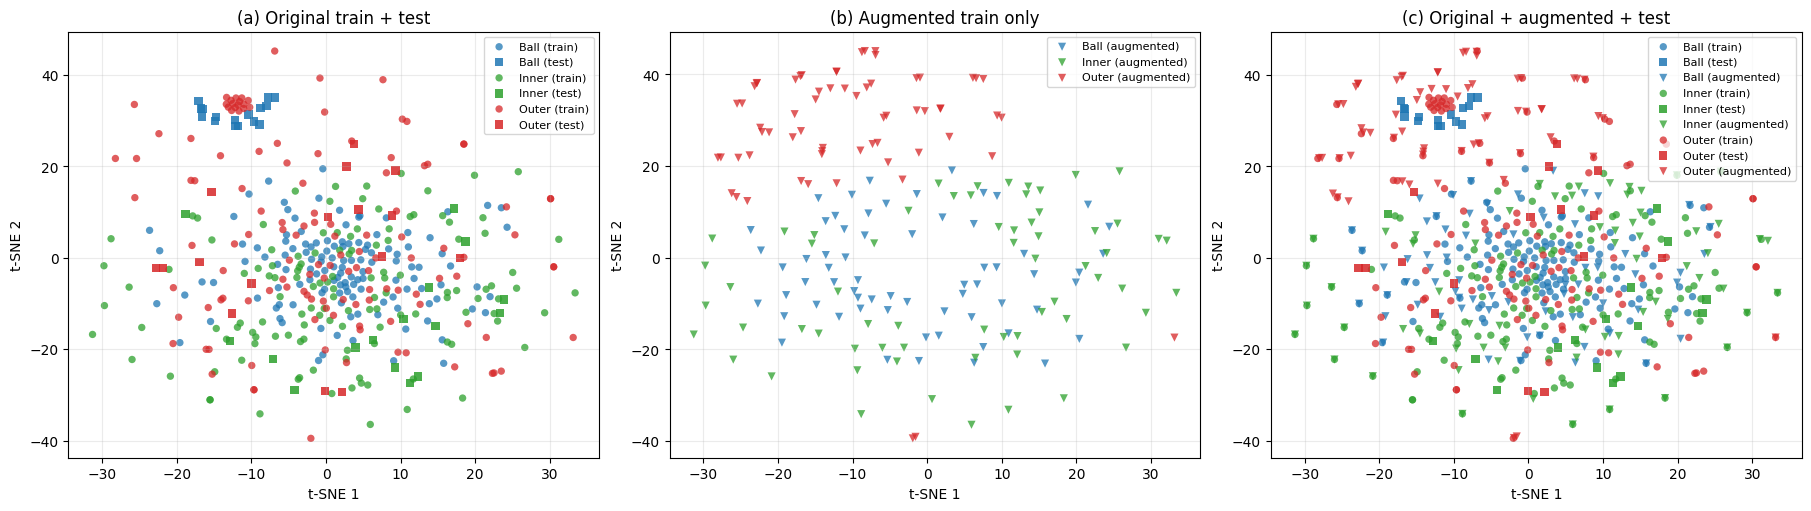

In [85]:
fig, embedding, metadata = plot_tsne_class_comparison(
    Xtr_ball=Xtr_ball,
    Xtr_inner=Xtr_inner,
    Xtr_outer=Xtr_outer,
    Xte_ball=Xte_ball,
    Xte_inner=Xte_inner,
    Xte_outer=Xte_outer,
    Xtr_ball_aug=Xaug_ball,
    Xtr_inner_aug=Xaug_inner,
    Xtr_outer_aug=Xaug_outer,
    perplexity=20,
    max_iter=1500,
    random_state=42,
    save_path="tsne_class_comparison.png",
)

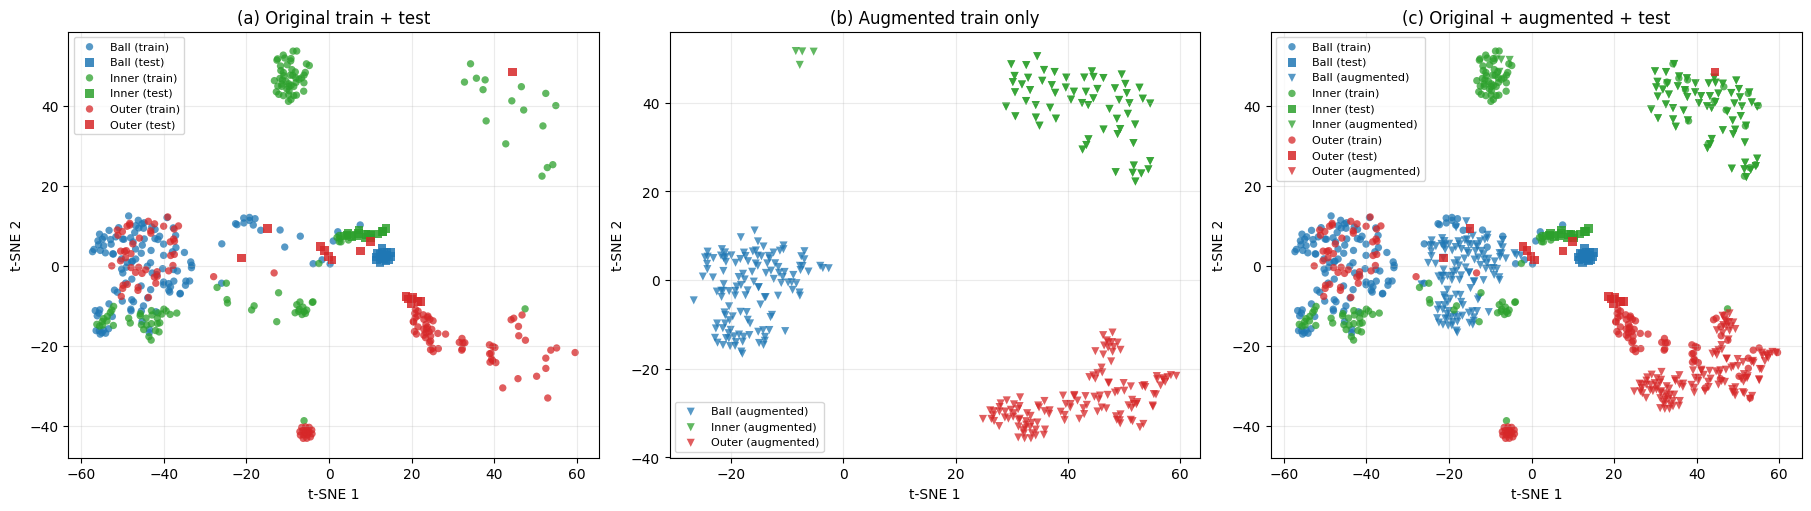

In [135]:
fig, embedding, metadata = plot_tsne_class_comparison_wpt(
    Xtr_ball=Xtr_ball,
    Xtr_inner=Xtr_inner,
    Xtr_outer=Xtr_outer,
    Xte_ball=Xte_ball,
    Xte_inner=Xte_inner,
    Xte_outer=Xte_outer,
    Xtr_ball_aug=Xaug_ball,
    Xtr_inner_aug=Xaug_inner,
    Xtr_outer_aug=Xaug_outer,
    wavelet='db4',
    mode='symmetric',
    maxlevel=4,
    perplexity=20,
    max_iter=1500,
    random_state=42,
    save_path="tsne_wpt_class_comparison.png",
)

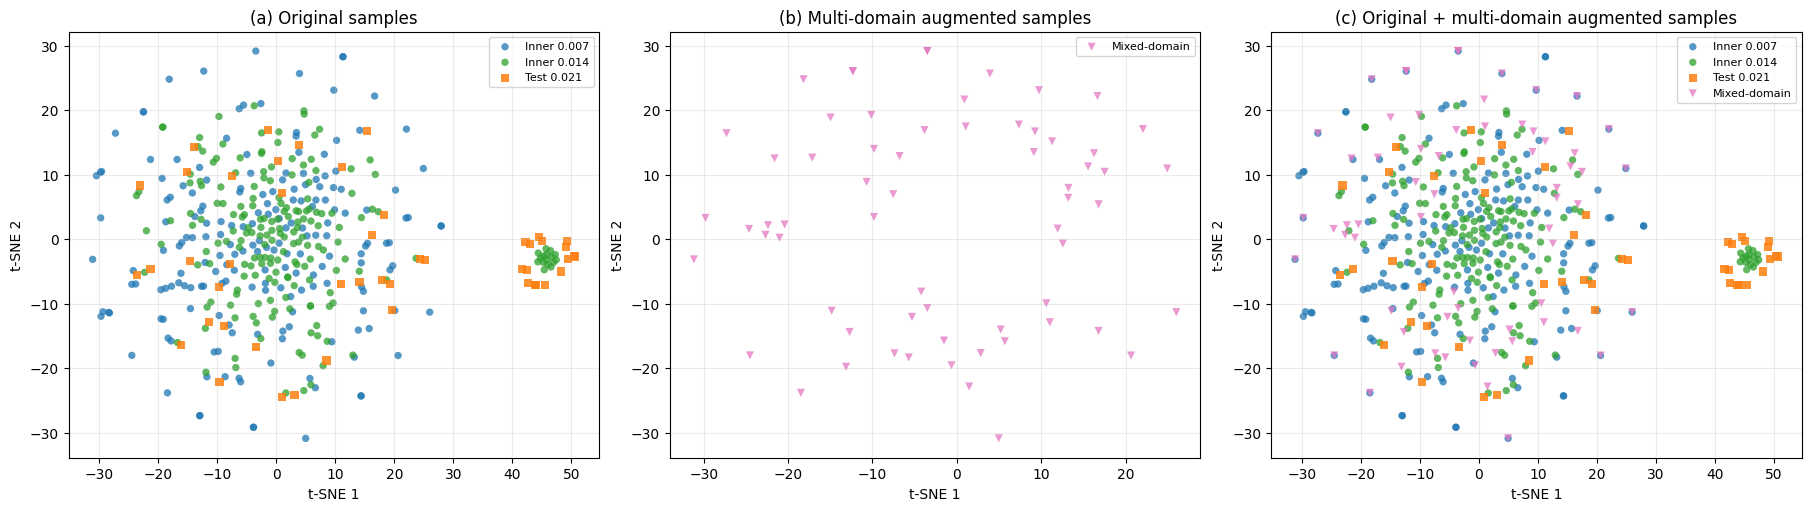

In [106]:
fig, embedding, metadata = plot_tsne_multidomain_three_scenarios(
    X_train_dom_1=X_train_dom_1,
    X_train_dom_2=X_train_dom_2,
    X_test=X_test,
    X_augmented=X_augmented,   # your mixed-domain samples
    domain_names=("Inner 0.007", "Inner 0.014", "Test 0.021", "Mixed-domain"),
    scenario_titles=(
        "(a) Original samples",
        "(b) Multi-domain augmented samples",
        "(c) Original + multi-domain augmented samples",
    ),
    perplexity=15,
    max_iter=1500,
    random_state=42,
    save_path="tsne_multidomain_inner.png",
)